# Homogeneous shard graph — VICReg node representation learning

**Two augmented views** of the same cleaned Step-2 shard graph; node features are **only** L2-normalized **mean-pooled shard embeddings** (no extra scalars). Each view uses light **edge dropout** and **feature dropout**. A **2-layer skip-GraphSAGE** produces **`z_pre = skip_alpha * h_gnn + (1 - skip_alpha) * proj(x)`** for both views. **VICReg** (invariance + variance + covariance) is computed on **raw `z_pre`** — no unit normalization inside the loss.

**Optimization:** `ReduceLROnPlateau` and **early stopping** on **`val_loss`** (VICReg with fixed val augmentation RNGs). **HDBSCAN** + email mapping is the **evaluation** metric; **best clustering epoch** is tracked separately (`embeddings_clustering_best.npy`) from **best loss** (`embeddings_best.npy`).

**Artifacts:** `analysis/output/shard_graph_homogeneous_gnn/<run_id>/`


## Why VICReg (instead of BGRL here)

BGRL/BYOL can **over-smooth** node geometry when the target is too aligned across views, which hurts **HDBSCAN** on normalized cones. **VICReg** couples two light graph views with three explicit terms:

1. **Invariance** — same shard should map similarly under augmentation (MSE between the two view embeddings).
2. **Variance** — each dimension must keep enough **spread across nodes** (hinge on a standard-deviation floor \(\gamma\)); fights **dimensional collapse**.
3. **Covariance** — penalize **off-diagonal** covariance so dimensions do not redundantly track the same factor.

**Clustering** uses the **learned raw** vectors `z_pre` (skip-blend output) by default—**no row L2 normalization** before HDBSCAN—so scale and spread from the variance term are visible to Euclidean HDBSCAN. Set `cluster_l2_normalize=True` in config to compare cone geometry.

**Diagnostics** (per-dim std, off-diagonal covariance mass, random-pair cosine, norm stats) show whether representations stay **spread out** across nodes.


In [1]:
from __future__ import annotations

import json
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

try:
    from IPython.display import display
except ImportError:
    display = print

_here = Path.cwd().resolve()
PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
assert (PROJECT_ROOT / "pipeline_config.json").is_file(), (
 f"Set cwd to repo root (contains pipeline_config.json); got {PROJECT_ROOT}"
)
sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils.semantic_shard_graph_helpers import load_step1_assignments
from analysis.utils.semantic_shard_helpers import load_transformer_cache
from analysis.utils.semantic_shard_step3_helpers import load_step2_artifacts
from analysis.utils.shard_homogeneous_gnn_experiment import (
    HomogeneousShardGNNConfig,
    build_homogeneous_shard_data,
    build_shard_node_features,
    load_ground_truth_map,
    shard_embeddings_to_email_metrics,
    train_homogeneous_shard_gnn,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEVICE:", DEVICE)


c:\Users\aar\Desktop\GNN-Campaign-Detection\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: C:\Users\aar\Desktop\GNN-Campaign-Detection
DEVICE: cpu


In [2]:
# --- Compact run config: change RUN_ID / paths here ---
# Step-2: same layout as semantic_shard_prototype_step3_community_detection.ipynb
# (CSV files live directly in this folder unless you use a per-run subfolder).
STEP2_BASE_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph"
STEP2_ROUTING_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph_routing"
USE_STEP2_ROUTING_GRAPH = False
STEP2_DIR = STEP2_ROUTING_DIR if USE_STEP2_ROUTING_GRAPH else STEP2_BASE_DIR

# Embeddings: same default as semantic_shard_prototype_step2_build_graph.ipynb
EMBEDDINGS_JSON = PROJECT_ROOT / "core" / "utils" / "embeddings" / "output" / "embeddings.json"

# Ground truth: semantic_shard_method2_diagnostics.ipynb (GT_JSON)
GT_JSON = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth.json"

cfg = HomogeneousShardGNNConfig(
    run_id="run_001",
    step2_dir=str(STEP2_DIR),
    step1_assignments_csv=str(
        PROJECT_ROOT
        / "analysis"
        / "output"
        / "semantic_shard_step1"
        / "semantic_shard_step1_assignments.csv"
    ),
    embeddings_json=str(EMBEDDINGS_JSON),
    ground_truth_json=str(GT_JSON),
    include_log_size=False,
    skip_alpha=0.5,
    seed=42,
    hidden_dim=128,
    out_dim=64,
    n_layers=2,
    dropout=0.2,
    lr=1e-3,
    weight_decay=3e-4,
    max_epochs=40,
    scheduler_patience=5,
    early_stopping_patience=10,
    edge_dropout_prob=0.08,
    feature_dropout_prob=0.1,
    vicreg_lambda=25.0,
    vicreg_mu=25.0,
    vicreg_nu=1.0,
    vicreg_gamma=1.0,
    cluster_l2_normalize=False,
    min_edge_weight=0.0,
    save_checkpoint_every_epoch=True,
    save_embeddings_every_epoch=True,
    hdbscan_min_cluster_size=8,
    hdbscan_min_samples=3,
    eval_every_epochs=1,
)

OUT_DIR = PROJECT_ROOT / "analysis" / "output" / "shard_graph_homogeneous_gnn" / cfg.run_id
OUT_DIR.mkdir(parents=True, exist_ok=True)
with open(OUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(cfg), f, indent=2)
print("OUT_DIR:", OUT_DIR)


OUT_DIR: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\shard_graph_homogeneous_gnn\run_001


## Load Step-2 graph, assignments, embeddings, GT

`cfg.step2_dir` defaults like **`semantic_shard_prototype_step3_community_detection.ipynb`**. Expected files: `semantic_shard_step2_nodes.csv`, `semantic_shard_step2_edges_weighted.csv`, `semantic_shard_step2_candidates.csv`.

**Node features** = mean of member vectors from **`embeddings_json`**, **L2-normalized per shard row only** (no shard-size or other scalars). This isolates whether **message passing** improves geometry over the **existing** embedding space.

Ground-truth labels: **`data/groundtruth/ground_truth.json`**, same as **`semantic_shard_method2_diagnostics.ipynb`** (`GT_JSON`). Loaded via `load_ground_truth_map` → `load_ground_truth_structures`.


In [3]:
nodes_df, edges_df, _candidates_df = load_step2_artifacts(cfg.step2_dir)
assert "shard_id" in nodes_df.columns

assignments_df = load_step1_assignments(cfg.step1_assignments_csv)
_payload, id_to_embedding, emb_summary = load_transformer_cache(cfg.embeddings_json)
print(
    "embeddings cache:",
    emb_summary.n_entries_with_any_vector,
    "vectors,",
    emb_summary.subj_dim + emb_summary.body_dim,
    "dims",
)

X, shard_ids, idx_map = build_shard_node_features(
    nodes_df,
    id_to_embedding,
    include_log_size=cfg.include_log_size,
)
gt = load_ground_truth_map(cfg.ground_truth_json)

data = build_homogeneous_shard_data(
    shard_ids,
    idx_map,
    edges_df,
    X,
    min_edge_weight=float(cfg.min_edge_weight),
)
undirected_edges = data.edge_index.size(1) // 2
print("# shard nodes (with emb):", data.num_nodes, " undirected edges:", int(undirected_edges))
print("feature shape:", tuple(X.shape))
if undirected_edges == 0:
    print("WARNING: no edges — VICReg training will exit immediately (no graph signal).")


embeddings cache: 5437 vectors, 2048 dims
# shard nodes (with emb): 1673  undirected edges: 1720
feature shape: (1673, 2048)


## Train VICReg (two graph views)

Each epoch: **independent** light augmentations (**edge dropout**, **feature dropout**) → skip-GraphSAGE **`z_pre`** for views A and B. **VICReg** aligns same-node outputs (**invariance** / MSE), enforces per-dimension spread (**variance** hinge with **`vicreg_gamma`**), and decorrelates dimensions (**covariance** off-diagonal penalty). Weights: **`vicreg_lambda`**, **`vicreg_mu`**, **`vicreg_nu`**.

**Validation `val_loss`** uses a second fixed-RNG augmentation pair (same VICReg total). **Scheduler** + **early stopping** follow **`val_loss`**. **Checkpoints:** **`embeddings_best.npy`** = lowest **`val_loss`**; **`embeddings_clustering_best.npy`** = best **`val_v_measure`**. Saved vectors are **raw `z_pre`** (training loss is **not** L2-normalized). HDBSCAN during training uses **`cfg.cluster_l2_normalize`** if you want row-L2 before clustering.

The cell below runs **HDBSCAN on raw `X`** once (baseline); training follows.


In [4]:
baseline = shard_embeddings_to_email_metrics(
    shard_ids,
    np.asarray(X, dtype=np.float32),
    assignments_df,
    gt,
    min_cluster_size=cfg.hdbscan_min_cluster_size,
    min_samples=cfg.hdbscan_min_samples,
    l2_normalize_rows=cfg.cluster_l2_normalize,
)
with open(OUT_DIR / "baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(baseline, f, indent=2)
print("Baseline (raw X):", {k: baseline.get(k) for k in ("v_measure", "homogeneity", "completeness", "coverage_gt", "coverage_assignments", "n_clusters", "n_noise_shards")})

Baseline (raw X): {'v_measure': 0.5789761718943512, 'homogeneity': 0.43984550206013623, 'completeness': 0.8468490334271421, 'coverage_gt': 1.0, 'coverage_assignments': 0.33175569078205996, 'n_clusters': 13.0, 'n_noise_shards': 1476.0}


In [5]:
history, training_summary = train_homogeneous_shard_gnn(
    cfg,
    data.to(DEVICE),
    shard_ids,
    assignments_df,
    gt,
    OUT_DIR,
    DEVICE,
    tqdm_epochs=tqdm,
)

hist_df = pd.DataFrame(history)
hist_df.to_csv(OUT_DIR / "training_history.csv", index=False)
with open(OUT_DIR / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

ev = hist_df.dropna(subset=["val_v_measure"])
if len(ev):
    best_vm_row = ev.loc[ev["val_v_measure"].idxmax()]
    print(
        "Peak val_v_measure in history: epoch",
        int(best_vm_row["epoch"]),
        float(best_vm_row["val_v_measure"]),
    )
print("training_summary:", training_summary)
ble = training_summary.get("best_loss_epoch", -1)
if ble is not None and ble >= 0:
    print(
        "Best val_loss checkpoint: epoch",
        ble,
        "val_loss",
        training_summary.get("best_val_loss"),
    )
bce = training_summary.get("best_clustering_epoch", -1)
if bce is not None and bce >= 0:
    print(
        "Best clustering (max val_v_measure): epoch",
        bce,
        "V-measure",
        training_summary.get("best_v_measure"),
    )


[BGRL shard] n_nodes=1673, directed_edges=3440 (~1720 undirected), edge_drop=0.08, feat_drop=0.1, ema=0.996


epochs: 100%|██████████| 40/40 [00:46<00:00,  1.17s/it, trn=0.0572, vl=0.0417, Vm=0.152]

Peak val_v_measure in history: epoch 1 0.1518147272244836
training_summary: {'best_loss_epoch': 38, 'best_val_loss': 0.037952885031700134, 'best_clustering_epoch': 1, 'best_v_measure': 0.1518147272244836, 'final_epoch': 40, 'stop_reason': 'max_epochs', 'stall_epochs_without_val_loss_improvement': 2}
Best val_loss checkpoint: epoch 38 val_loss 0.037952885031700134
Best clustering (max val_v_measure): epoch 1 V-measure 0.1518147272244836


## Clustering evaluation (email-level)

**HDBSCAN** on shard vectors, then shard predictions mapped to emails. Default: **raw** learned `z_pre` from disk (no row L2 unless **`cfg.cluster_l2_normalize`** was `True` during training eval and you use the same flag below). The table compares:

- **baseline_raw_X** — `baseline_metrics.json` (input **X** rows; already L2-normalized per shard in feature builder)
- **gnn_best_val_loss** — `embeddings_best.npy`
- **gnn_best_clustering_vm** — `embeddings_clustering_best.npy` if present
- **gnn_final** — `embeddings_final.npy`

Partial GT coverage is handled inside **`shard_embeddings_to_email_metrics`**.


In [6]:
baseline_path = OUT_DIR / "baseline_metrics.json"
if baseline_path.exists():
    with open(baseline_path, encoding="utf-8") as f:
        metrics_baseline = json.load(f)
else:
    metrics_baseline = shard_embeddings_to_email_metrics(
        shard_ids,
        np.asarray(X, dtype=np.float32),
        assignments_df,
        gt,
        min_cluster_size=cfg.hdbscan_min_cluster_size,
        min_samples=cfg.hdbscan_min_samples,
    )

final_z = np.load(OUT_DIR / "embeddings_final.npy")
best_path = OUT_DIR / "embeddings_best.npy"
if best_path.exists():
    best_z = np.load(best_path)
else:
    print("No embeddings_best.npy; using final.")
    best_z = final_z

clust_path = OUT_DIR / "embeddings_clustering_best.npy"
if clust_path.exists():
    clust_best_z = np.load(clust_path)
else:
    clust_best_z = None

_hdb_kw = dict(
    min_cluster_size=cfg.hdbscan_min_cluster_size,
    min_samples=cfg.hdbscan_min_samples,
    l2_normalize_rows=cfg.cluster_l2_normalize,
)

metrics_best = shard_embeddings_to_email_metrics(
    shard_ids, best_z, assignments_df, gt, **_hdb_kw
)
metrics_final = shard_embeddings_to_email_metrics(
    shard_ids, final_z, assignments_df, gt, **_hdb_kw
)
if clust_best_z is not None:
    metrics_clust = shard_embeddings_to_email_metrics(
        shard_ids, clust_best_z, assignments_df, gt, **_hdb_kw
    )
else:
    metrics_clust = None

EVAL_KEYS = (
    "homogeneity",
    "completeness",
    "v_measure",
    "coverage_gt",
    "coverage_assignments",
    "n_eval",
    "n_clusters",
    "n_noise_shards",
)


def _row(name: str, m: dict) -> dict:
    r = {"checkpoint": name}
    r.update({k: m.get(k) for k in EVAL_KEYS})
    return r


rows = [
    _row("baseline_raw_X", metrics_baseline),
    _row("gnn_best_val_loss", metrics_best),
]
if metrics_clust is not None:
    rows.append(_row("gnn_best_clustering_vm", metrics_clust))
rows.append(_row("gnn_final", metrics_final))

eval_table = pd.DataFrame(rows)
display(eval_table)
eval_table.to_csv(OUT_DIR / "gnn_clustering_metrics.csv", index=False)

full_summary: dict = {
    "training_summary": training_summary,
    "baseline_raw_X": metrics_baseline,
    "gnn_best_val_loss": metrics_best,
    "gnn_final": metrics_final,
}
if metrics_clust is not None:
    full_summary["gnn_best_clustering_vm"] = metrics_clust
with open(OUT_DIR / "evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump(full_summary, f, indent=2)

for label, m in (
    ("Baseline (raw X)", metrics_baseline),
    ("GNN best val_loss", metrics_best),
    *(
        (("GNN best clustering (V-measure)", metrics_clust),)
        if metrics_clust is not None
        else ()
    ),
    ("GNN final epoch", metrics_final),
):
    print(f"\n--- {label} ---")
    for k in EVAL_KEYS:
        print(f"  {k}: {m.get(k)}")
    for k in ("n_shard_nodes",):
        if k in m:
            print(f"  {k}: {m[k]}")


,checkpoint,homogeneity,completeness,v_measure,coverage_gt,coverage_assignments,n_eval,n_clusters,n_noise_shards
0,baseline_raw_X,0.439846,0.846849,0.578976,1.0,0.331756,1472.0,13.0,1476.0
1,gnn_best_val_loss,0.086367,0.626787,0.151815,1.0,0.331756,1472.0,2.0,0.0
2,gnn_best_clustering_vm,0.086367,0.626787,0.151815,1.0,0.331756,1472.0,2.0,0.0
3,gnn_final,0.086367,0.626787,0.151815,1.0,0.331756,1472.0,2.0,0.0



--- Baseline (raw X) ---
  homogeneity: 0.43984550206013623
  completeness: 0.8468490334271421
  v_measure: 0.5789761718943512
  coverage_gt: 1.0
  coverage_assignments: 0.33175569078205996
  n_eval: 1472.0
  n_clusters: 13.0
  n_noise_shards: 1476.0
  n_shard_nodes: 1673.0

--- GNN best val_loss ---
  homogeneity: 0.08636687045329358
  completeness: 0.6267868589959545
  v_measure: 0.1518147272244836
  coverage_gt: 1.0
  coverage_assignments: 0.33175569078205996
  n_eval: 1472.0
  n_clusters: 2.0
  n_noise_shards: 0.0
  n_shard_nodes: 1673.0

--- GNN best clustering (V-measure) ---
  homogeneity: 0.08636687045329358
  completeness: 0.6267868589959545
  v_measure: 0.1518147272244836
  coverage_gt: 1.0
  coverage_assignments: 0.33175569078205996
  n_eval: 1472.0
  n_clusters: 2.0
  n_noise_shards: 0.0
  n_shard_nodes: 1673.0

--- GNN final epoch ---
  homogeneity: 0.08636687045329358
  completeness: 0.6267868589959545
  v_measure: 0.1518147272244836
  coverage_gt: 1.0
  coverage_assignm

## Plots

Training **VICReg** total loss, **LR**, **HDBSCAN metrics**, then **spread** diagnostics on **raw eval z** (mean per-dim std, off-diagonal covariance energy), **unweighted VICReg terms** (train), and **random-pair cosine** / **||z||** summaries.


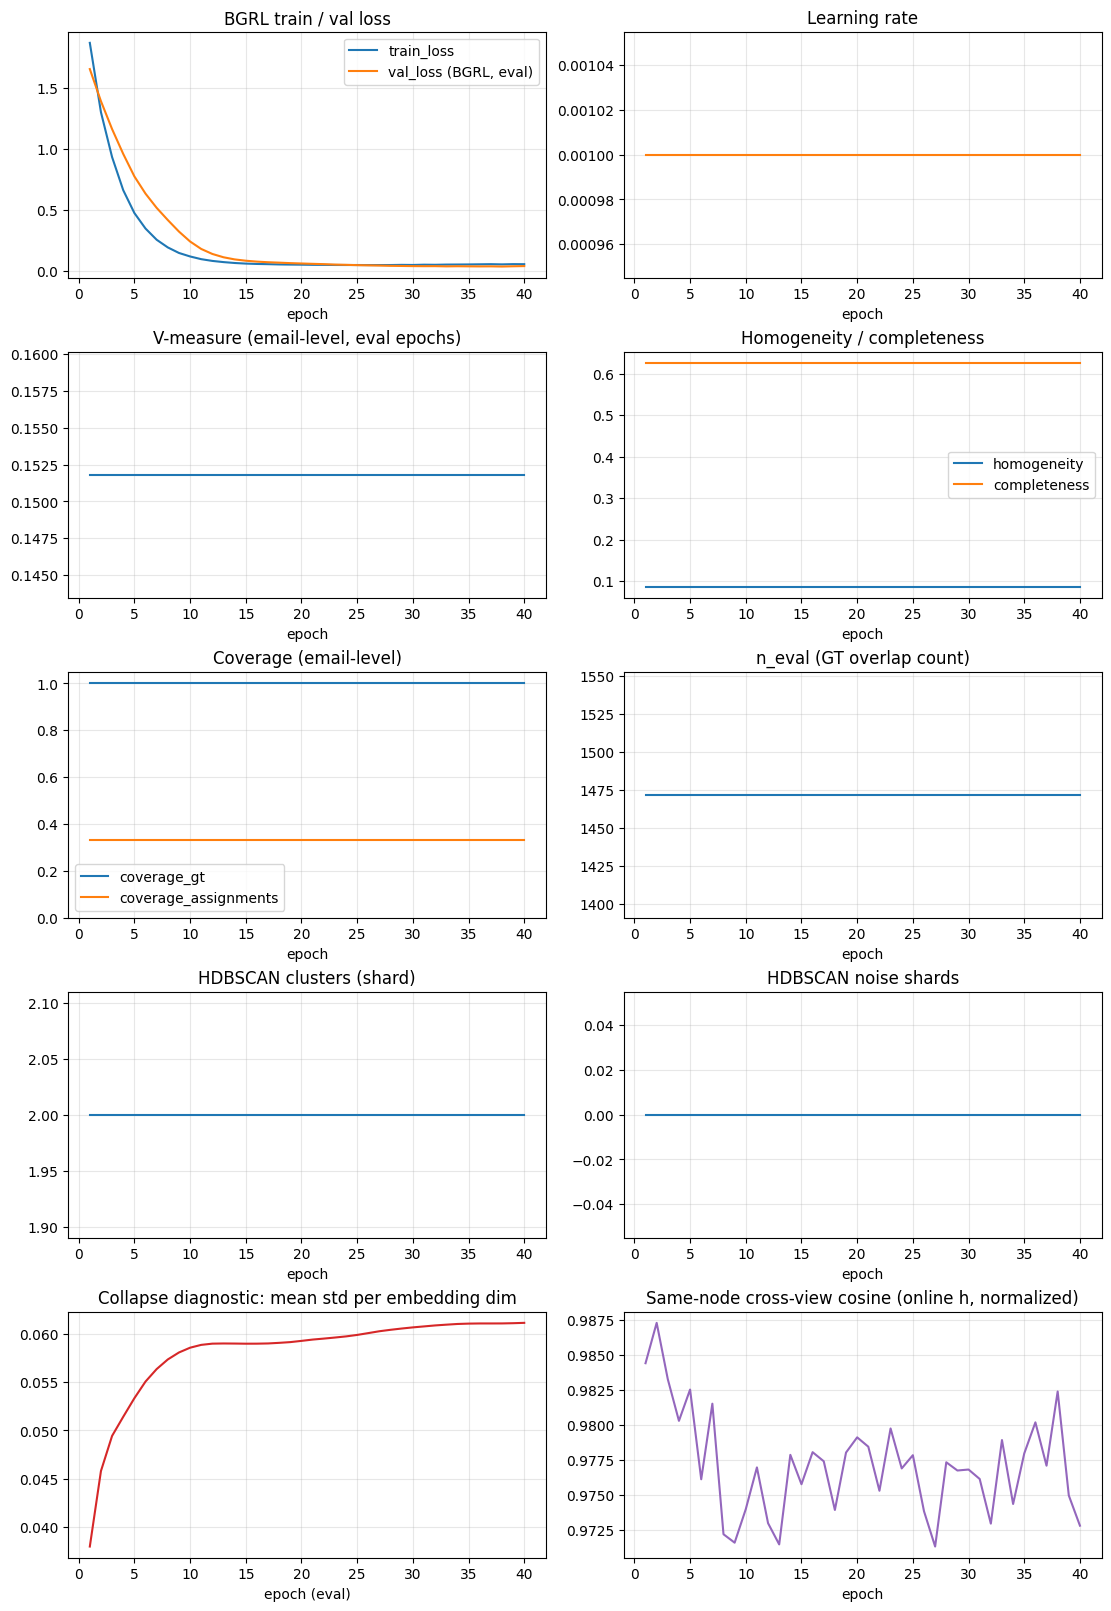

In [8]:
ev = hist_df.dropna(subset=["val_v_measure"])
de = hist_df.dropna(subset=["diag_emb_mean_std_dim"])
dcv = hist_df.dropna(subset=["diag_offdiag_cov_per_dim"])

fig, axes = plt.subplots(6, 2, figsize=(11, 20), constrained_layout=True)
axes[0, 0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
if "val_loss" in hist_df.columns:
    axes[0, 0].plot(
        hist_df["epoch"], hist_df["val_loss"], label="val_loss (VICReg, eval)"
    )
axes[0, 0].legend()
axes[0, 0].set_title("VICReg train / val loss (weighted total)")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(hist_df["epoch"], hist_df["lr"], color="tab:orange")
axes[0, 1].set_title("Learning rate")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].grid(True, alpha=0.3)

if len(ev):
    axes[1, 0].plot(ev["epoch"], ev["val_v_measure"])
axes[1, 0].set_title("V-measure (email-level, eval epochs)")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].grid(True, alpha=0.3)

if len(ev):
    axes[1, 1].plot(ev["epoch"], ev["val_homogeneity"], label="homogeneity")
    axes[1, 1].plot(ev["epoch"], ev["val_completeness"], label="completeness")
axes[1, 1].legend()
axes[1, 1].set_title("Homogeneity / completeness")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].grid(True, alpha=0.3)

if len(ev):
    axes[2, 0].plot(ev["epoch"], ev["val_coverage_gt"], label="coverage_gt")
    if "val_coverage_assignments" in ev.columns:
        axes[2, 0].plot(
            ev["epoch"],
            ev["val_coverage_assignments"],
            label="coverage_assignments",
        )
axes[2, 0].set_title("Coverage (email-level)")
axes[2, 0].set_xlabel("epoch")
axes[2, 0].set_ylim(0.0, 1.05)
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

if len(ev):
    axes[2, 1].plot(ev["epoch"], ev["val_n_eval"])
axes[2, 1].set_title("n_eval (GT overlap count)")
axes[2, 1].set_xlabel("epoch")
axes[2, 1].grid(True, alpha=0.3)

if len(ev):
    axes[3, 0].plot(ev["epoch"], ev["val_n_clusters"])
axes[3, 0].set_title("HDBSCAN clusters (shard)")
axes[3, 0].set_xlabel("epoch")
axes[3, 0].grid(True, alpha=0.3)

if len(ev):
    axes[3, 1].plot(ev["epoch"], ev["val_n_noise_shards"])
axes[3, 1].set_title("HDBSCAN noise shards")
axes[3, 1].set_xlabel("epoch")
axes[3, 1].grid(True, alpha=0.3)

if len(de):
    axes[4, 0].plot(de["epoch"], de["diag_emb_mean_std_dim"], color="tab:red")
axes[4, 0].set_title("Mean std per embedding dim (eval, raw z)")
axes[4, 0].set_xlabel("epoch (eval)")
axes[4, 0].grid(True, alpha=0.3)

if len(dcv):
    axes[4, 1].plot(
        dcv["epoch"], dcv["diag_offdiag_cov_per_dim"], color="tab:green"
    )
axes[4, 1].set_title("Off-diag cov energy ||offdiag(C)||_F^2 / D (eval)")
axes[4, 1].set_xlabel("epoch (eval)")
axes[4, 1].grid(True, alpha=0.3)

vt = hist_df.dropna(subset=["vicreg_train_inv"])
if len(vt):
    axes[5, 0].plot(vt["epoch"], vt["vicreg_train_inv"], label="inv (MSE)")
    axes[5, 0].plot(vt["epoch"], vt["vicreg_train_var"], label="var (unweighted)")
    axes[5, 0].plot(vt["epoch"], vt["vicreg_train_cov"], label="cov (unweighted)")
axes[5, 0].legend()
axes[5, 0].set_title("VICReg components (train, unweighted)")
axes[5, 0].set_xlabel("epoch")
axes[5, 0].grid(True, alpha=0.3)

rp = hist_df.dropna(subset=["diag_rand_pair_cosine"])
if len(rp):
    axes[5, 1].plot(rp["epoch"], rp["diag_rand_pair_cosine"], label="rand pair cos")
if "diag_emb_norm_mean" in hist_df.columns:
    nm = hist_df.dropna(subset=["diag_emb_norm_mean"])
    if len(nm):
        axes[5, 1].plot(nm["epoch"], nm["diag_emb_norm_mean"], label="||z|| mean")
axes[5, 1].legend()
axes[5, 1].set_title("Geometry: random-pair cosine & ||z|| (eval)")
axes[5, 1].set_xlabel("epoch")
axes[5, 1].grid(True, alpha=0.3)

fig.savefig(OUT_DIR / "training_plots.png", dpi=160)
plt.show()


## Rerun HDBSCAN only

Load `embeddings_best.npy`, `embeddings_clustering_best.npy`, `embeddings_final.npy`, or `embeddings/epoch_XXXX.npy`, then call `shard_embeddings_to_email_metrics(..., l2_normalize_rows=cfg.cluster_l2_normalize)` with the same HDBSCAN hyperparameters. Arrays on disk are **raw skip-blend `z_pre`**; set `l2_normalize_rows=True` only if you want row L2 before HDBSCAN.
